# Maternal Health Risk Prediction: A Machine Learning Approach for Low-Resource Settings

## 1. Problem Framing

Maternal mortality remains one of the most persistent and preventable crises in global health.
Sub-Saharan Africa accounts for roughly 70% of all maternal deaths worldwide, with most
occurring not from untreatable conditions, but from delays — in recognition, in referral,
in care. A woman in this region is approximately 130 times more likely to die from a
pregnancy-related cause than a woman in a high-income country.

The gap is not purely a resource problem. It is an information and education problem.

At the frontline of maternal care in low-resource settings — the rural clinic, the primary
health centre, the community midwife — the tools available are often basic: a blood pressure
cuff, a thermometer, a glucometer. What is frequently absent is a structured, evidence-based
way to translate those readings into a risk decision. Which patients need immediate referral?
Who can be safely monitored? When is watchful waiting appropriate and when is it dangerous?

This project explores whether a machine learning model trained on routinely collectable maternal vitals — age, blood pressure, blood glucose, body temperature, and heart rate —
can reliably stratify pregnant women into low, medium, and high risk categories. The goal
is not to replace clinical judgment, but to augment it: to give a nurse or midwife working
alone, without specialist backup, a data-informed second opinion.

### Clinical Context
The features in this dataset are deliberately low-tech. No imaging. No specialist labs.
No equipment that requires calibration or electricity beyond the basics. This constraint
is intentional — a model is only useful if it can run where the problem actually exists.

### Why This Matters for Machine Learning
Beyond the humanitarian framing, this is an interesting ML problem. The target variable
has three classes (low, mid, high risk) with real-world class imbalance implications.
Critically, the cost of errors is asymmetric: **a false negative on a high-risk patient
is far more dangerous than a false positive.** This shapes every modelling and evaluation
decision that follows.



## 2. Dataset

The Dataset: UCI Maternal Health Risk
This dataset was collected from hospitals, community clinics, and maternal health centres in rural Bangladesh through an IoT-based risk monitoring system. It has 1,014 rows and 7 columns:


## 3. Exploratory Data Analysis
Before building any model, we need to understand what the data is actually saying.
This EDA is structured around five clinical questions that will directly inform our
modelling decisions.*italicized text*

In [1]:
# Exploring Data
# Import Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(r'C:\Users\HP\Desktop\PORTFOLIO\Health\maternal+health+risk\Maternal Health Risk Data Set.csv')
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [2]:
# Checking the shape of the dataset
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

Shape: (1014, 7)

Column names: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


### 3.1 Data Quality
Checking for missing values, duplicate rows, and whether feature ranges make clinical sense. In a clinical dataset, an outlier can be an error or a genuinely extreme case.


In [3]:
print(" MISSING VALUES ")
print(df.isnull().sum())

print("\n DUPLICATE ROWS ")
print(f"Duplicates: {df.duplicated().sum()}")

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DESCRIPTIVE STATISTICS ===")
df.describe().round(2)

 MISSING VALUES 
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

 DUPLICATE ROWS 
Duplicates: 562

=== DATA TYPES ===
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

=== DESCRIPTIVE STATISTICS ===


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.00,1014.0,1014.00,1014.00,1014.00,1014.00
mean,29.87,113.2,76.46,8.73,98.67,74.30
std,13.47,18.4,13.89,3.29,1.37,8.09
min,10.00,70.0,49.00,6.00,98.00,7.00
25%,19.00,100.0,65.00,6.90,98.00,70.00
50%,26.00,120.0,80.00,7.50,98.00,76.00
75%,39.00,120.0,90.00,8.00,98.00,80.00
max,70.00,160.0,100.00,19.00,103.00,90.00


In [4]:
# Looking at the duplicates themselves
duplicates = df[df.duplicated(keep=False)]
print(f"Rows involved in duplication: {len(duplicates)}")

# How are duplicates distributed across risk levels?
print("\nDuplicate distribution by risk level:")
print(df[df.duplicated(keep='first')]['RiskLevel'].value_counts())

# Compare class distribution before and after
print("\nOriginal class distribution:")
print(df['RiskLevel'].value_counts())

Rows involved in duplication: 866

Duplicate distribution by risk level:
RiskLevel
mid risk     230
low risk     172
high risk    160
Name: count, dtype: int64

Original class distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


Duplicates aren't spread evenly across all three risk classes, concentration is seen at the mid risk class, dropping them could worsen class imbalance.

### Clinical Reference Check

We compare observed ranges against established clinical thresholds to flag 
implausible values:

| Feature | Normal Range | Clinical Concern |
|---|---|---|
| SystolicBP | 90–120 mmHg | >140 = hypertension, <90 = hypotension |
| DiastolicBP | 60–80 mmHg | >90 = hypertension |
| BS | 3.9–7.8 mmol/L (fasting) | >7.8 = gestational diabetes risk |
| BodyTemp | 36.1–37.2°C / 97–99°F | >38°C = fever, possible sepsis |
| HeartRate | 60–100 bpm | >100 = tachycardia |

Any values outside these ranges are not automatically errors but indicates risk and need for further investigations.

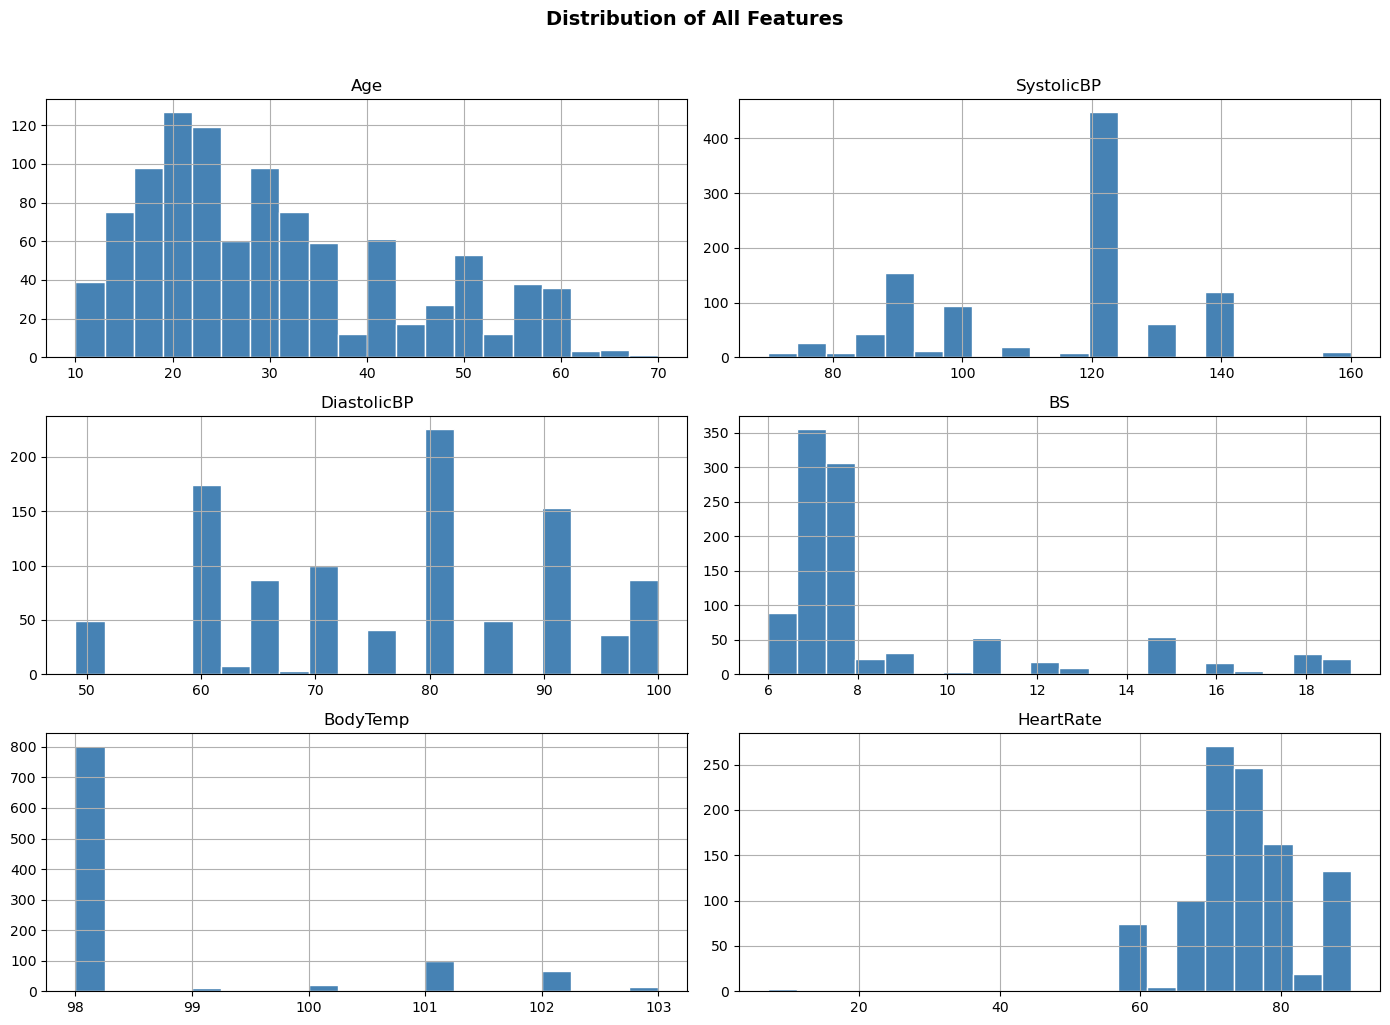

In [5]:
#Histogram showing distribution of all features.
df.hist(figsize=(14, 10), bins=20, edgecolor='white', color='steelblue')
plt.suptitle("Distribution of All Features", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

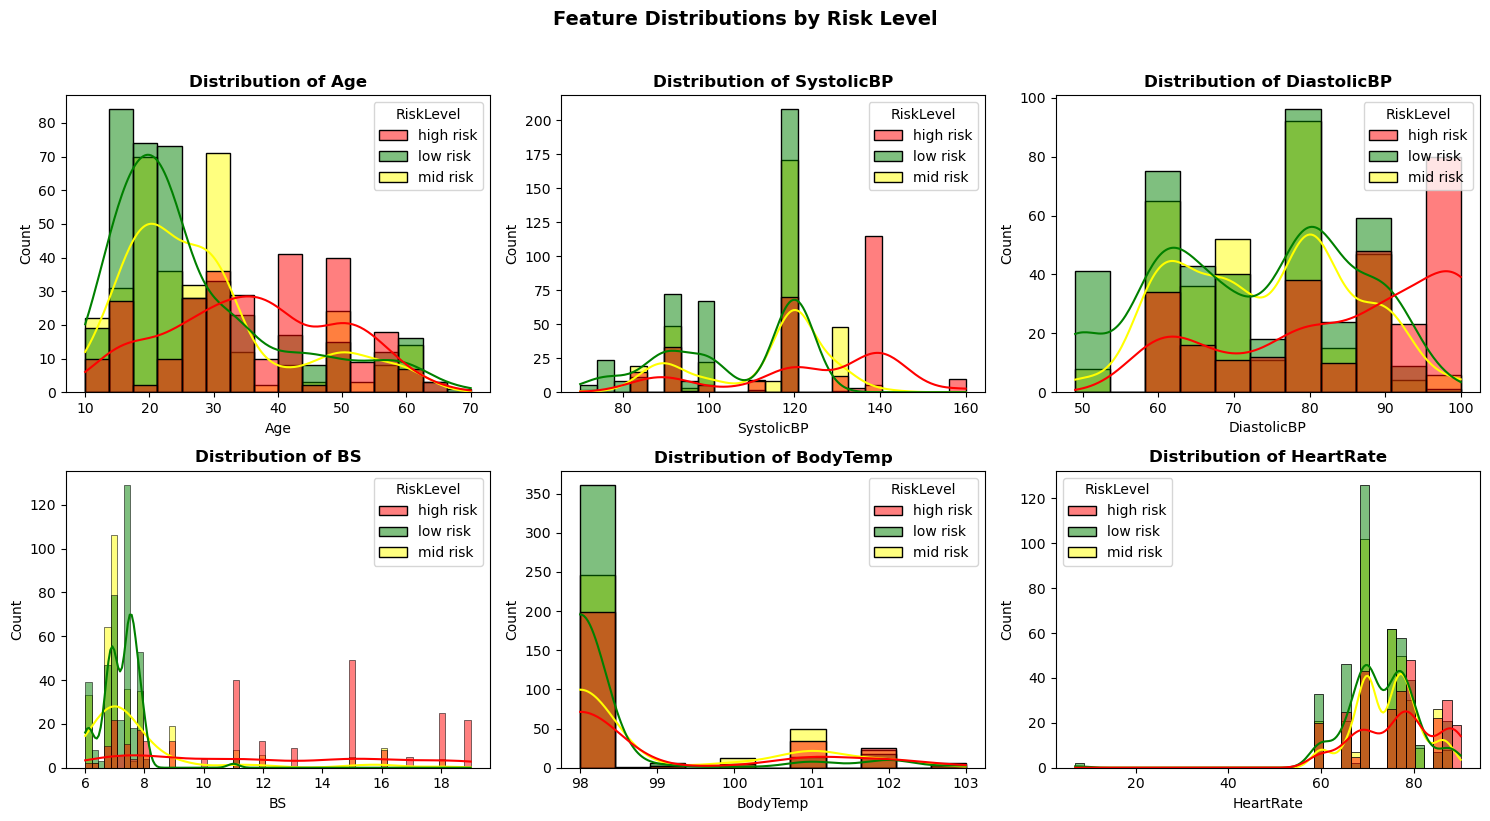

In [6]:
features = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, hue="RiskLevel", kde=True,
                 palette={"low risk": 'green', "mid risk": "yellow", "high risk":'red'},
                 alpha=0.5, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}", fontweight="bold")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.suptitle("Feature Distributions by Risk Level", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("histograms.png", dpi=150, bbox_inches="tight")
plt.show()

#### Distribution by risk Level
The plot above indicates the following:

1. Women of younger age group (15-25) had much lower risk and women in the middle age had highest maternal mortality risk.

2. Most people who are at higher risk for maternal mortality have a systolic blood pressure of 140mmHg, and the trend line declines from the 140 mark and at 130mmHg, there is no low risk class.

3. The blood sugar distribution showed that from 8mmol/L, there's a high risk prevalence.

4. Temperature distribution shows that temperature is a poor determiner of maternal mortality risk as the highest range of high risk mothers fall within the normal temperature range.


In [7]:
# convert the temperature from Fahrenheit to Celsius
df['BodyTemp_C'] = (df['BodyTemp'] - 32) * 5.0/9.0
print(df['BodyTemp_C'].min())
print(df['BodyTemp_C'].max())

36.666666666666664
39.44444444444444


In [8]:
#Flag clinically impossible data such as age >60

df_filtered = df[(df['Age'] >= 10) & (df['Age'] <= 60)]

### 3.2 Class Distribution
In clinical risk stratification, class imbalance is common — high-risk patients 
are by definition rarer. If high-risk cases are underrepresented, a model can achieve high accuracy by simply predicting low-risk for everyone, while completely 
failing the patients who matter most.

Text(0.5, 1.0, 'Risk Level Distribution')

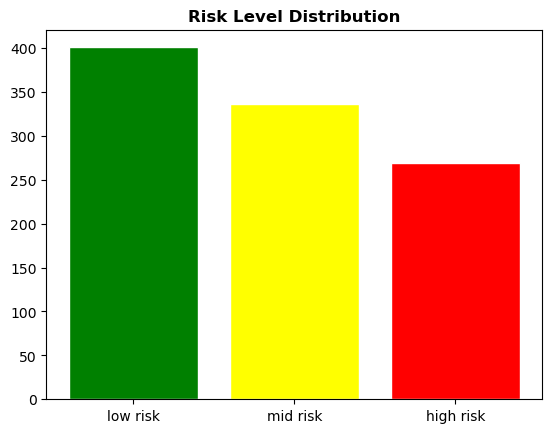

In [9]:
distribution = df_filtered['RiskLevel'].value_counts()
plt.bar(distribution.index, distribution.values, color=['green', 'yellow', 'red'], edgecolor='white')
plt.title("Risk Level Distribution", fontweight="bold")

### 3.3 Age Distribution and Risk

Maternal age is a well-established risk factor — adolescent pregnancies (<18) and 
advanced maternal age (>35) both carry elevated complication risks. We examine 
whether this pattern holds in the data.

C:\Users\HP\AppData\Local\Temp\ipykernel_40312\3796792617.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["AgeGroup"] = pd.cut(df_filtered["Age"], bins=bins, labels=labels, right=False)


 HIGH RISK % BY AGE GROUP 
RiskLevel  high risk  low risk  mid risk
AgeGroup                                
<18             19.2      53.4      27.5
18–25            4.5      55.5      40.0
26–35           29.0      26.5      44.5
>35             48.7      28.4      22.9


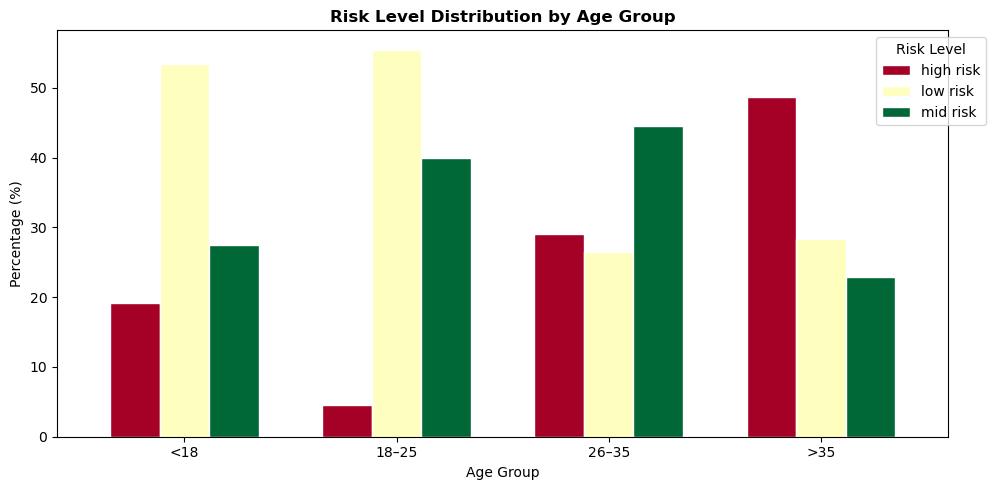

In [10]:
# Age group binning
bins = [0, 18, 25, 35, 100]
labels = ["<18", "18–25", "26–35", ">35"]
df_filtered["AgeGroup"] = pd.cut(df_filtered["Age"], bins=bins, labels=labels, right=False)

# Cross-tabulation
age_risk = pd.crosstab(df_filtered["AgeGroup"], df_filtered["RiskLevel"], normalize="index") * 100
print(" HIGH RISK % BY AGE GROUP ")
print(age_risk.round(1))

# Plot
age_risk.plot(kind="bar", cmap='RdYlGn', figsize=(10, 5), 
              edgecolor="white", width=0.7)
plt.title("Risk Level Distribution by Age Group", fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.legend(title="Risk Level", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("age_risk.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Feature Correlations and Risk Co-occurrence

A single abnormal reading can be an anomaly. Multiple abnormal readings together 
are a pattern. We examine correlations between features and look specifically at 
whether high-risk patients tend to present with co-occurring abnormalities — 
which would have significant implications for how the model should weight 
combined signals.

C:\Users\HP\AppData\Local\Temp\ipykernel_40312\756414766.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["RiskEncoded"] = df_filtered["RiskLevel"].map(risk_map)


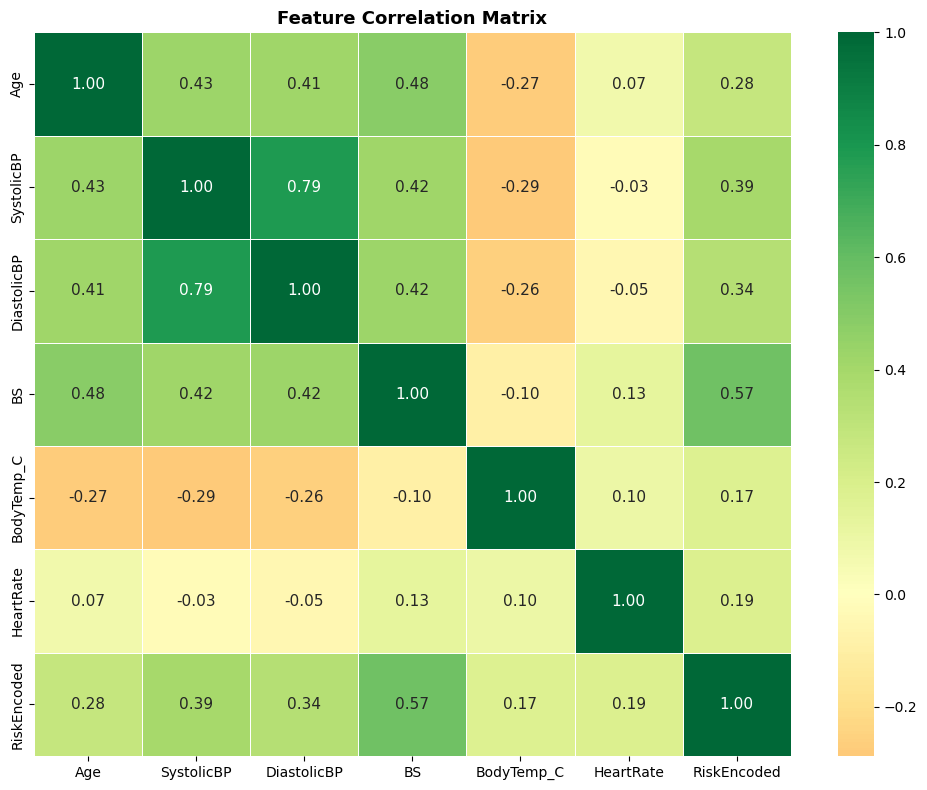

 CORRELATION WITH RISK LEVEL
BS             0.566
SystolicBP     0.392
DiastolicBP    0.344
Age            0.280
HeartRate      0.189
BodyTemp_C     0.173
Name: RiskEncoded, dtype: float64


In [11]:
# Encode risk level for correlation
risk_map = {"low risk": 0, "mid risk": 1, "high risk": 2}
df_filtered["RiskEncoded"] = df_filtered["RiskLevel"].map(risk_map)

corr_cols = ["Age", "SystolicBP", "DiastolicBP", "BS", 
             "BodyTemp_C", "HeartRate", "RiskEncoded"]
corr_matrix = df_filtered[corr_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,  annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    annot_kws={"size": 11}
)
plt.title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Top correlates with risk
print(" CORRELATION WITH RISK LEVEL")
print(corr_matrix["RiskEncoded"].drop("RiskEncoded")
      .sort_values(ascending=False).round(3))

### 3.5 EDA SUMMARY: What the Data told us:

1. Age is a major risk in maternal mortality

## 4.0

In [12]:
print(corr_matrix)

                  Age  SystolicBP  DiastolicBP        BS  BodyTemp_C  \
Age          1.000000    0.430800     0.411895  0.482413   -0.273138   
SystolicBP   0.430800    1.000000     0.785769  0.421015   -0.287530   
DiastolicBP  0.411895    0.785769     1.000000  0.422500   -0.260853   
BS           0.482413    0.421015     0.422500  1.000000   -0.099969   
BodyTemp_C  -0.273138   -0.287530    -0.260853 -0.099969    1.000000   
HeartRate    0.069898   -0.029336    -0.050257  0.134310    0.103446   
RiskEncoded  0.280138    0.391882     0.344337  0.565827    0.172867   

             HeartRate  RiskEncoded  
Age           0.069898     0.280138  
SystolicBP   -0.029336     0.391882  
DiastolicBP  -0.050257     0.344337  
BS            0.134310     0.565827  
BodyTemp_C    0.103446     0.172867  
HeartRate     1.000000     0.188820  
RiskEncoded   0.188820     1.000000  


In [13]:
#Top 5 correlations 
top_corr = corr_matrix["RiskEncoded"].drop("RiskEncoded").abs().sort_values(ascending=False).head(5)
print("\n TOP 5 CORRELATIONS WITH RISK LEVEL")
print(top_corr)


 TOP 5 CORRELATIONS WITH RISK LEVEL
BS             0.565827
SystolicBP     0.391882
DiastolicBP    0.344337
Age            0.280138
HeartRate      0.188820
Name: RiskEncoded, dtype: float64


In [14]:
df_new = df_filtered[corr_cols].copy()
print(df_new.head())

   Age  SystolicBP  DiastolicBP    BS  BodyTemp_C  HeartRate  RiskEncoded
0   25         130           80  15.0   36.666667         86            2
1   35         140           90  13.0   36.666667         70            2
2   29          90           70   8.0   37.777778         80            2
3   30         140           85   7.0   36.666667         70            2
4   35         120           60   6.1   36.666667         76            0


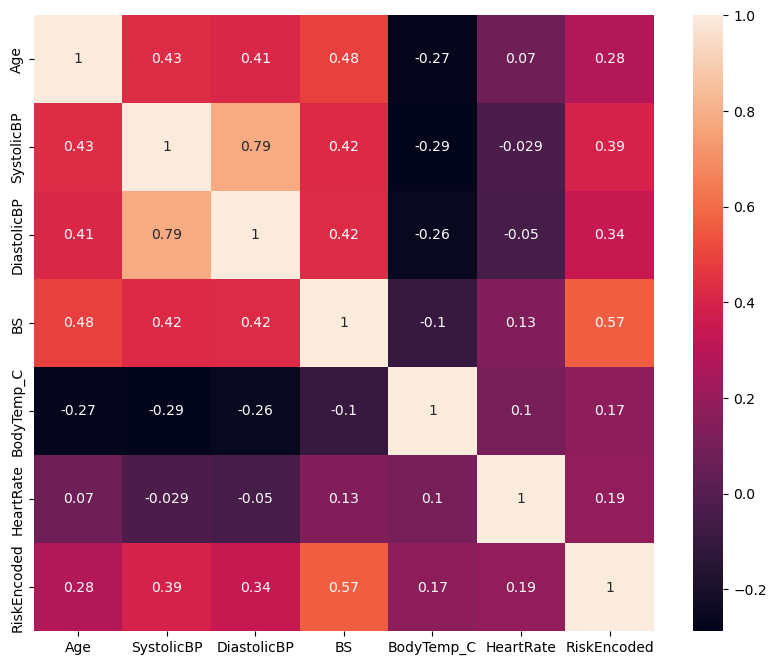

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df_new.corr(),annot=True)
plt.show()

## 3. Preprocessing

With the data understood, we now prepare it for modelling. Every decision here 
is deliberate — driven by what the EDA revealed, not a generic pipeline template.